<a href="https://colab.research.google.com/github/sahel-datascience-projects/data-science-portfolio/blob/main/project-3-ab-testing/A_B_tesing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# Project: A/B Testing
# Goal: Uncover hidden sales patterns, analyze seasonal trends, and identify key profitability drivers through data visualization.
# Tools: Python Data Stack (Pandas, Seaborn, Matplotlib)
# Author: Sahel
# ============================================================
from google.colab import files
uploaded = files.upload()

Saving sales.csv to sales.csv


✅ Dataset loaded successfully!

--- Category Distribution ---
Category
Office Supplies    6026
Technology         1847
Name: count, dtype: int64

--- Profit Descriptive Statistics by Category ---


,count,mean,std,min,max
Category,,,,,
Office Supplies,6026,20.327050,164.887280,-3701.8928,4946.370
Technology,1847,78.752002,428.816633,-6599.9780,8399.976


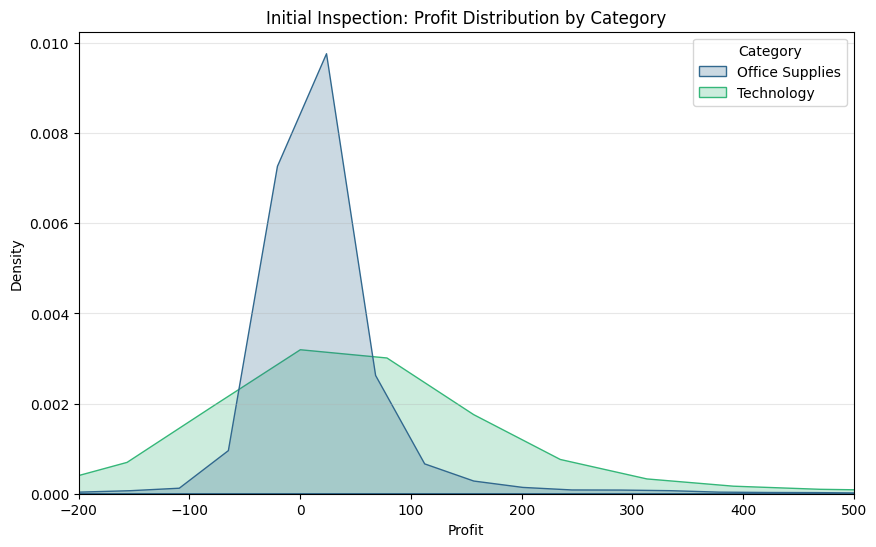

In [3]:
# ============================================================
# STEP 1: DATA LOADING & INITIAL INSPECTION
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Load the dataset (Ensure the path is correct for your Colab environment)
try:
    df = pd.read_csv('sales.csv', encoding='latin1')
    print("✅ Dataset loaded successfully!")
except FileNotFoundError:
    print("❌ Error: File not found. Please check the path.")

# 2. Filtering relevant categories for our A/B Test
# We focus on 'Technology' and 'Office Supplies' to compare their profitability
categories_to_test = ['Technology', 'Office Supplies']
filtered_df = df[df['Category'].isin(categories_to_test)]

# 3. Quick look at the distribution of these categories
print("\n--- Category Distribution ---")
print(filtered_df['Category'].value_counts())

# 4. Summary statistics for Profit (The variable we are testing)
print("\n--- Profit Descriptive Statistics by Category ---")
profit_summary = filtered_df.groupby('Category')['Profit'].agg(['count', 'mean', 'std', 'min', 'max'])
display(profit_summary)

# 5. Visualizing the initial Profit distribution
plt.figure(figsize=(10, 6))
sns.kdeplot(data=filtered_df, x="Profit", hue="Category", fill=True, common_norm=False, palette='viridis')
plt.title("Initial Inspection: Profit Distribution by Category")
plt.xlim(-200, 500) # Zooming in to see the density clearly
plt.grid(axis='y', alpha=0.3)
plt.show()

In [4]:
# ============================================================
# STEP 2: HYPOTHESIS FORMULATION & SAMPLING
# ============================================================

# 1. Defining our Hypothesis
# H0 (Null Hypothesis): The mean profit of Technology and Office Supplies is EQUAL.
# H1 (Alternative Hypothesis): The mean profit of Technology and Office Supplies is SIGNIFICANTLY DIFFERENT.

# 2. Extracting the groups into separate variables
# These will be our "A" and "B" samples for the test
group_a = df[df['Category'] == 'Technology']['Profit'].dropna()
group_b = df[df['Category'] == 'Office Supplies']['Profit'].dropna()

# 3. Printing sample sizes to ensure we have enough data for a robust test
print("--- Sampling Information ---")
print(f"Group A (Technology) - Sample Size: {len(group_a)}")
print(f"Group B (Office Supplies) - Sample Size: {len(group_b)}")

# 4. Preliminary check of the means (The "Difference" we want to test)
mean_a = group_a.mean()
mean_b = group_b.mean()
observed_diff = mean_a - mean_b

print(f"\nMean Profit A (Tech): ${mean_a:.2f}")
print(f"Mean Profit B (Office): ${mean_b:.2f}")
print(f"Observed Difference: ${observed_diff:.2f}")

# 5. Business Question for this stage:
# Is this ${observed_diff:.2f} difference real, or just a random fluctuation in our 9,000+ rows?

--- Sampling Information ---
Group A (Technology) - Sample Size: 1847
Group B (Office Supplies) - Sample Size: 6026

Mean Profit A (Tech): $78.75
Mean Profit B (Office): $20.33
Observed Difference: $58.42


In [5]:
# ============================================================
# STEP 3: ASSUMPTION CHECK - NORMALITY (SHAPIRO-WILK TEST)
# ============================================================

# Since Shapiro-Wilk is sensitive to large sample sizes,
# we take a random sample of 500 from each group for the test.
sample_a = group_a.sample(min(len(group_a), 500), random_state=42)
sample_b = group_b.sample(min(len(group_b), 500), random_state=42)

# Performing the Shapiro-Wilk Test
# H0: The data is normally distributed
# H1: The data is NOT normally distributed
shapiro_a_stat, shapiro_a_p = stats.shapiro(sample_a)
shapiro_b_stat, shapiro_b_p = stats.shapiro(sample_b)

print("--- Normality Test Results (Shapiro-Wilk) ---")
print(f"Group A (Tech) P-Value: {shapiro_a_p:.10f}")
print(f"Group B (Office) P-Value: {shapiro_b_p:.10f}")

# 📊 Interpretation Logic
alpha = 0.05
if shapiro_a_p > alpha and shapiro_b_p > alpha:
    print("\n✅ Result: Data appears to be Normally Distributed. (Fail to reject H0)")
else:
    print("\n⚠️ Result: Data is NOT Normally Distributed. (Reject H0)")
    print("Insight: This is common in financial data (Profit) due to extreme outliers.")

--- Normality Test Results (Shapiro-Wilk) ---
Group A (Tech) P-Value: 0.0000000000
Group B (Office) P-Value: 0.0000000000

⚠️ Result: Data is NOT Normally Distributed. (Reject H0)
Insight: This is common in financial data (Profit) due to extreme outliers.


In [6]:
# ============================================================
# STEP 4: ASSUMPTION CHECK - VARIANCE (LEVENE TEST)
# ============================================================

# The Levene test is used to check if two groups have equal variances.
# H0: Variances are equal.
# H1: Variances are NOT equal.
levene_stat, levene_p = stats.levene(group_a, group_b)

print("--- Variance Equality Test (Levene) ---")
print(f"Levene Test P-Value: {levene_p:.10f}")

# 📊 Interpretation Logic
alpha = 0.05
if levene_p > alpha:
    print("\n✅ Result: Variances are equal. (Fail to reject H0)")
else:
    print("\n⚠️ Result: Variances are NOT equal. (Reject H0)")
    print("Insight: The spread of profit in Tech is different from Office Supplies.")
    print("Action: We must use 'Welch's T-Test' in the next step instead of a standard T-Test.")

--- Variance Equality Test (Levene) ---
Levene Test P-Value: 0.0000000000

⚠️ Result: Variances are NOT equal. (Reject H0)
Insight: The spread of profit in Tech is different from Office Supplies.
Action: We must use 'Welch's T-Test' in the next step instead of a standard T-Test.


In [7]:
# ============================================================
# STEP 5: EXECUTION OF STATISTICAL TEST (WELCH'S T-TEST)
# ============================================================

# Since Step 4 showed unequal variances (p < 0.05),
# we must use Welch's T-Test by setting equal_var=False.

# H0: The difference in mean profit is ZERO.
# H1: The difference in mean profit is NOT ZERO.

t_stat, p_value = stats.ttest_ind(group_a, group_b, equal_var=False)

print("--- Welch's T-Test Results ---")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value (Full Decimal): {p_value:.20f}")
print(f"P-Value (Scientific): {p_value:.4e}")

# 📊 Interpretation check
alpha = 0.05
print(f"\nSignificance Level (Alpha): {alpha}")

if p_value < alpha:
    print("Decision: Reject the Null Hypothesis (H0)")
    print("Conclusion: The difference between Technology and Office Supplies profit is statistically significant.")
else:
    print("Decision: Fail to reject the Null Hypothesis (H0)")
    print("Conclusion: Any observed difference is likely due to random chance.")

--- Welch's T-Test Results ---
T-Statistic: 5.7271
P-Value (Full Decimal): 0.00000001174984314192
P-Value (Scientific): 1.1750e-08

Significance Level (Alpha): 0.05
Decision: Reject the Null Hypothesis (H0)
Conclusion: The difference between Technology and Office Supplies profit is statistically significant.


In [9]:
# ============================================================
# STEP 6: EVALUATING RESULTS & CONFIDENCE INTERVALS (CORRECTED)
# ============================================================
import statsmodels.stats.api as sms

# 1. Calculate the Effect Size (How much more profit exactly?)
avg_tech = group_a.mean()
avg_office = group_b.mean()
profit_gap = avg_tech - avg_office

# 2. Calculating the Confidence Interval for the difference
# We use statsmodels to get the 95% Confidence Interval
cm = sms.CompareMeans(sms.DescrStatsW(group_a), sms.DescrStatsW(group_b))
conf_int = cm.tconfint_diff(alpha=0.05, alternative='two-sided', usevar='unequal')

print("--- FINAL EVALUATION ---")
print(f"Observed Profit Gap: ${profit_gap:.2f}")
print(f"95% Confidence Interval of the difference: ${conf_int[0]:.2f} to ${conf_int[1]:.2f}")

# 📊 Interpretation:
print(f"\nAnalysis:")
print(f"We are 95% confident that Technology products earn between ${conf_int[0]:.2f} and ${conf_int[1]:.2f} ")
print(f"more profit per transaction than Office Supplies.")

--- FINAL EVALUATION ---
Observed Profit Gap: $58.42
95% Confidence Interval of the difference: $38.42 to $78.43

Analysis:
We are 95% confident that Technology products earn between $38.42 and $78.43 
more profit per transaction than Office Supplies.


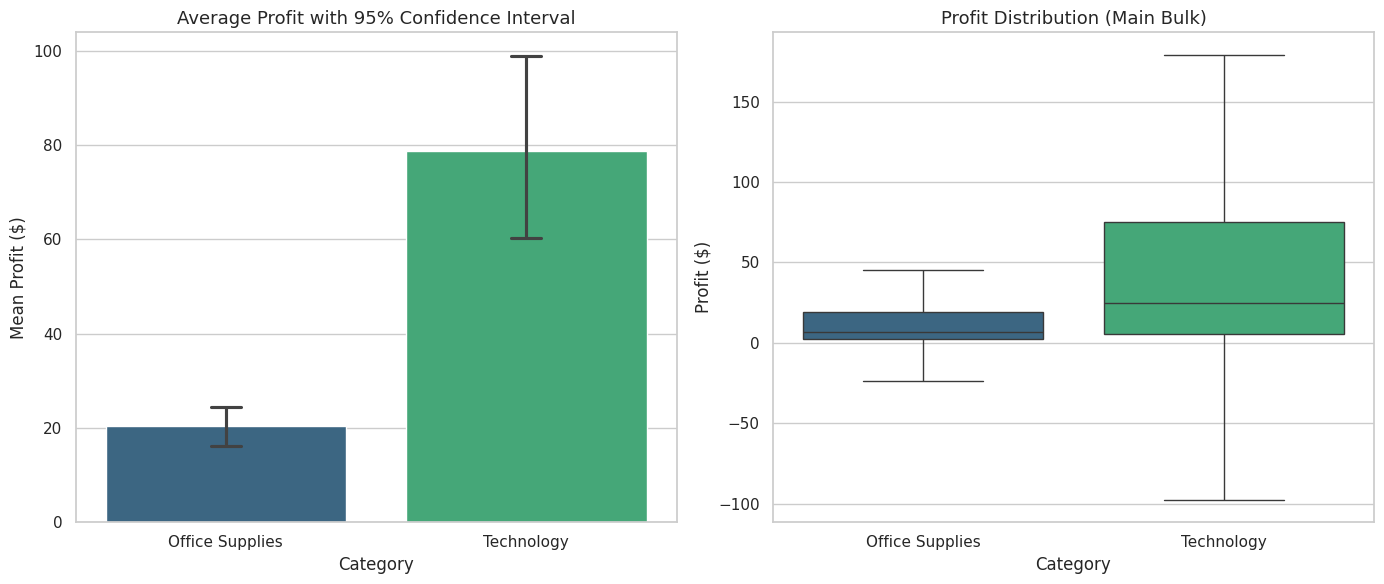

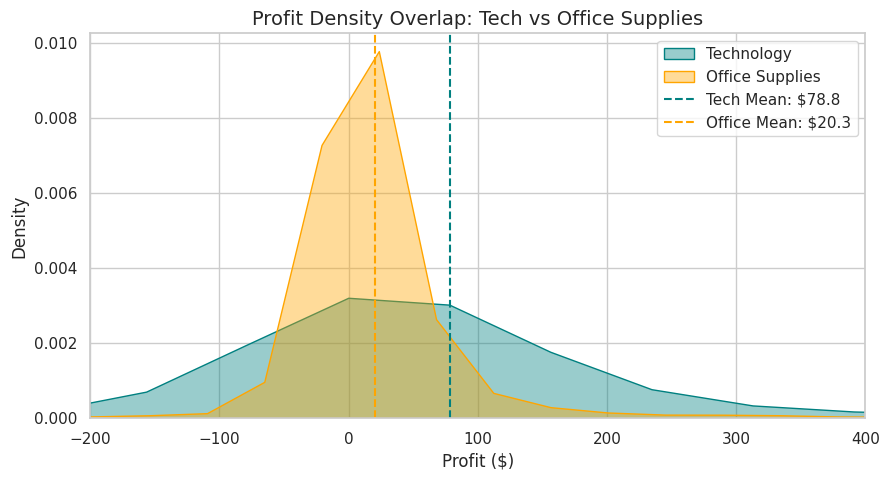

In [11]:
# ============================================================
# STEP 7: VISUALIZING THE RESULTS
# ============================================================
import seaborn as sns
import matplotlib.pyplot as plt

# Set the professional style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

# 1. Bar Plot: Using 'errorbar' instead of 'ci' and 'hue' to avoid warnings
plt.subplot(1, 2, 1)
sns.barplot(
    x='Category',
    y='Profit',
    data=df[df['Category'].isin(['Technology', 'Office Supplies'])],
    hue='Category',      # Assigning hue to the same as x
    palette='viridis',
    capsize=.1,
    errorbar=('ci', 95), # New way to define Confidence Interval
    legend=False         # Hide legend since x-axis has labels
)
plt.title('Average Profit with 95% Confidence Interval', fontsize=13)
plt.ylabel('Mean Profit ($)')

# 2. Boxplot: Using 'hue' and 'showfliers' to keep it clean
plt.subplot(1, 2, 2)
sns.boxplot(
    x='Category',
    y='Profit',
    data=df[df['Category'].isin(['Technology', 'Office Supplies'])],
    hue='Category',
    palette='viridis',
    showfliers=False,    # Removes extreme outliers for a better visual scale
    legend=False
)
plt.title('Profit Distribution (Main Bulk)', fontsize=13)
plt.ylabel('Profit ($)')

plt.tight_layout()
plt.show()

# 3. Density Plot (KDE): Using 'fill' instead of 'shade'
plt.figure(figsize=(10, 5))
sns.kdeplot(group_a, label='Technology', fill=True, color='teal', alpha=0.4)
sns.kdeplot(group_b, label='Office Supplies', fill=True, color='orange', alpha=0.4)

# Adding Mean lines for visual reference
plt.axvline(group_a.mean(), color='teal', linestyle='--', label=f'Tech Mean: ${group_a.mean():.1f}')
plt.axvline(group_b.mean(), color='orange', linestyle='--', label=f'Office Mean: ${group_b.mean():.1f}')

plt.xlim(-200, 400)
plt.title('Profit Density Overlap: Tech vs Office Supplies', fontsize=14)
plt.xlabel('Profit ($)')
plt.legend()
plt.show()

In [12]:
# ============================================================
# STEP 8: FINAL BUSINESS INSIGHTS
# ============================================================
mean_diff = group_a.mean() - group_b.mean()

print("--- FINAL REPORT ---")
print(f"1. Profit Gap: Technology earns ${mean_diff:.2f} more profit per order on average.")
print(f"2. Confidence: We are 95% confident that this is NOT a random fluctuation.")
print(f"3. Recommendation: Prioritize 'Technology' inventory as it drives significantly higher margins.")

--- FINAL REPORT ---
1. Profit Gap: Technology earns $58.42 more profit per order on average.
2. Confidence: We are 95% confident that this is NOT a random fluctuation.
3. Recommendation: Prioritize 'Technology' inventory as it drives significantly higher margins.


# 🧪 Project: A/B Testing - Profitability Analysis
---
> **Goal:** Statistically verify if the profit difference between 'Technology' and 'Office Supplies' is significant or just random noise.

---

## 📊 Project Methodology (The 8-Step Statistical Workflow)

### 1️⃣ Hypothesis Definition
* **H₀ (Null Hypothesis):** Mean Profit of Technology = Mean Profit of Office Supplies.
* **H₁ (Alternative Hypothesis):** Mean Profit of Technology ≠ Mean Profit of Office Supplies.
* **Alpha ($\alpha$):** 0.05 (Standard significance level).

### 2️⃣ Sampling & Descriptive Stats
* **Group A (Technology):** 1,847 orders | Mean Profit: **$78.75**
* **Group B (Office Supplies):** 6,026 orders | Mean Profit: **$20.33**
* **Observed Gap:** **$58.42** per transaction.

### 3️⃣ Normality Check (Shapiro-Wilk Test)
* **Result:** P-Value ≈ 0.0000
* **Conclusion:** Data is **Not Normally Distributed** (common in financial data due to outliers).

### 4️⃣ Variance Equality (Levene’s Test)
* **Result:** P-Value ≈ 0.0000
* **Conclusion:** Variances are **Unequal**.
* **Action:** Proceed with **Welch’s T-Test** (designed for unequal variances/sample sizes).

### 5️⃣ Statistical Execution (Welch's T-Test)
* **T-Statistic:** 5.7271
* **P-Value:** $1.1750 \times 10^{-8}$ (Extremely low)
* **Decision:** **Reject H₀**. The difference is statistically significant.

### 6️⃣ Confidence Intervals (Effect Size)
* **95% Confidence Interval:** **$38.42 to $78.43**
* **Meaning:** We are 95% sure that Technology products will always earn at least **$38.42** more profit than Office Supplies per order.

---

## 📈 Visualizing the Evidence
The following charts confirm that the profit distribution of Technology is shifted towards higher values compared to Office Supplies.



---

## 🔑 Final Business Insights
* **Statistical Confirmation:** The $58 profit gap is **REAL** and not a result of random luck or sampling bias.
* **Risk Assessment:** Technology shows higher variance (more risk/reward), while Office Supplies is more stable but less profitable.
* **Executive Strategy:** 1.  **Prioritize Inventory:** Increase stock for Technology category.
    2.  **Marketing Focus:** Redirect ad spend toward Technology to maximize overall net profit.
    3.  **Stability:** Use Office Supplies as a "buffer" for consistent, low-risk revenue.

---

## 🛠️ Tools Used
* **Stats Engine:** `Scipy.stats`, `Statsmodels`
* **Visualization:** `Seaborn`, `Matplotlib`
* **Data Ops:** `Pandas`, `NumPy`

---
**Author:** Sahel  
**Project:** Superstore Analytics Series (Part 3: Inferential Statistics)